# uv-scaling check on the existing gap injection-recovery results

The `*_lambda.vis.npz` files convert u, v from metres to wavelengths with **one** wavelength: uvplot's 0.8877 mm, i.e. ν_ref ≈ 337.7 GHz. The data actually span 330.5–345.8 GHz, with a data-weighted mean near 331.9 GHz. An injection placed at radius r therefore lands at about r × ν_ref / ν_row. The expected radial scale factor for each target is `scale = ν_ref / ν_weighted_mean` ≈ 1.017, taken from `nu_weighted_mean.txt`, which `nu_weighted_mean.py` computes from each MS with CASA.

- **Check 1:** in the existing recoveries, is the recovered radius about `scale` × the injected radius?
- **Check 2:** if the recovery criterion uses the scaled expected position, do the recovery curves and the 50% flux threshold (F50) change?

The inputs are all 19 `recoveries/*_recoveries.combined.txt` files in `gap/` and `inner_cavity/`. The recovery criteria are the same as in `assess_recovery.ipynb`: criterion A (Reid et al. 1988) and criterion B (Cycle 7 Handbook), each with a 2-pixel floor at 2σ.

In check 1, `ratio_det` and `ratio_SNR>10` count only sources that passed criterion A. Criterion A rejects peaks far from the *unscaled* position, which pulls those ratios toward 1. The `no-cut SNR>10` column uses every injection with F > 10 × the image RMS and is the fairer number.

In [1]:
import glob, os, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as disk

npix_tol, ast_tol = 2, 2
scales = {l.split()[0]: float(l.split()[5]) for l in open(r"D:\CPD_MPIA\HPC_eqC1_gap\nu_weighted_mean.txt") if not l.startswith('#')}
files = sorted(glob.glob(r"D:\CPD_MPIA\HPC_eqC1_gap\gap\*\recoveries\*_recoveries.combined.txt") +
               glob.glob(r"D:\CPD_MPIA\HPC_eqC1_gap\inner_cavity\*\recoveries\*_recoveries.combined.txt"))
print(len(files), 'combined recovery files')

def recovered(xe, ye, xr, yr, sigma, pix_size):
    # same criterion as assess_recovery.ipynb, against an expected position (xe, ye)
    return np.hypot(xe - xr, ye - yr) <= np.maximum(ast_tol * sigma, npix_tol * pix_size)

def frac(is_rec, Fi, Fcpd):
    return np.array([np.mean(is_rec[Fi == F]) for F in Fcpd])

def F50(Fcpd, fr):
    # first flux where the recovery fraction reaches 0.5, linearly interpolated
    i = np.argmax(fr >= 0.5)
    return np.nan if fr[i] < 0.5 else (Fcpd[0] if i == 0 else np.interp(0.5, fr[i - 1:i + 1], Fcpd[i - 1:i + 1]))

19 combined recovery files


In [2]:
R = []
for f in files:
    folder = os.path.basename(os.path.dirname(os.path.dirname(f)))
    target = os.path.basename(f).split('_gap')[0]
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(f).T
    scale = scales[target]

    # injected position (disk-polar -> sky), as in assess_recovery.ipynb
    azir = np.radians(azi)
    inclr, PAr = np.radians(disk.disk[target]['incl']), np.radians(disk.disk[target]['PA'])
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)

    hd = fits.getheader(sorted(glob.glob(os.path.dirname(f) + '/*.resid.fits'))[0])
    beam_fwhm = np.sqrt(3600**2 * hd['BMAJ'] * hd['BMIN'])
    pix_size = np.abs(3600 * hd['CDELT2'])
    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    freq, wave = hd['CRVAL3'], 2.99792e5 / hd['CRVAL3']
    Bmax_km = (wave * np.hypot(vdat['u'], vdat['v'])).max()
    sigma_A = (4 / np.pi)**0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)

    rec_A_old = recovered(xi, yi, xr, yr, sigma_A, pix_size)
    rec_B_old = recovered(xi, yi, xr, yr, sigma_B, pix_size)
    rec_A_new = recovered(scale * xi, scale * yi, xr, yr, sigma_A, pix_size)
    rec_B_new = recovered(scale * xi, scale * yi, xr, yr, sigma_B, pix_size)

    # check 1: radial ratio of the recovered sources (criterion A, original)
    r_inj, r_rec = np.hypot(xi, yi), np.hypot(xr, yr)
    snr = Fi / disk.disk[target]['RMS']   # injected flux in units of the image RMS (the rms column is the local annulus noise)
    bright = rec_A_old & (snr > 10)
    bright_all = snr > 10   # every bright injection, whether or not it passed criterion A
    Fcpd = np.unique(Fi)
    R.append(dict(folder=folder, target=target, scale=scale, r_inj=np.median(r_inj), beam_mas=1000 * beam_fwhm, pix_mas=1000 * pix_size,
                  n_det=rec_A_old.sum(), n_bright=bright.sum(),
                  ratio_det=np.median((r_rec / r_inj)[rec_A_old]), ratio_bright=np.median((r_rec / r_inj)[bright]),
                  ratio_bright_all=np.median((r_rec / r_inj)[bright_all]),
                  dr_bright_mas=np.median(1000 * (r_rec - r_inj)[bright]), dr_expected_mas=1000 * (scale - 1) * np.median(r_inj),
                  Fcpd=Fcpd, Fi=Fi, ratio_all=r_rec / r_inj, rec_A_old=rec_A_old,
                  fA_old=frac(rec_A_old, Fi, Fcpd), fA_new=frac(rec_A_new, Fi, Fcpd),
                  fB_old=frac(rec_B_old, Fi, Fcpd), fB_new=frac(rec_B_new, Fi, Fcpd), N=np.array([np.sum(Fi == F) for F in Fcpd])))

print(f"{'folder':24s} {'scale':>7s} {'r_inj\"':>7s} {'n_det':>6s} {'n_SNR>10':>8s} {'ratio_det':>9s} {'ratio_SNR>10':>12s} {'no-cut SNR>10':>13s} {'dr_SNR>10':>9s} {'dr_exp':>7s} {'beam':>5s} {'pix':>4s}  (dr, beam, pix in mas)")
for r in R:
    print(f"{r['folder']:24s} {r['scale']:7.4f} {r['r_inj']:7.3f} {r['n_det']:6d} {r['n_bright']:8d} {r['ratio_det']:9.4f} {r['ratio_bright']:12.4f} {r['ratio_bright_all']:13.4f} "
          f"{r['dr_bright_mas']:9.1f} {r['dr_expected_mas']:7.1f} {r['beam_mas']:5.0f} {r['pix_mas']:4.0f}")

C:\Users\LHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\LHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


folder                     scale  r_inj"  n_det n_SNR>10 ratio_det ratio_SNR>10 no-cut SNR>10 dr_SNR>10  dr_exp  beam  pix  (dr, beam, pix in mas)
AA_Tau_gap0               1.0173   0.106   1460     1207    1.0340       1.0327        1.0244       3.7     1.8    59    6
AA_Tau_gap1               1.0173   0.452   3483     1504    1.0120       1.0130        1.0148       5.7     7.8    59    6
DM_Tau_gap1               1.0174   0.436   3962     2042    1.0131       1.0144        1.0163       6.1     7.6    59    6
HD_135344B_C1             1.0174   0.289   1150      743    1.0047       0.9995        1.0501      -0.1     5.0    79    6
HD_135344B_C2             1.0174   0.508    112       96    1.0260       1.0260        1.1217      14.5     8.8    79    6
HD_135344B_DF             1.0174   0.670   3250     1000    1.0091       1.0242        1.0242      16.6    11.6    79    6
HD_135344B_gap0           1.0174   0.479      0        0       nan          nan        1.1350       nan     8.3    

## Check 1: radial ratio r_rec / r_inj against injected flux

The medians use recovered sources only (criterion A), in each flux bin with more than 5 recoveries. The dashed line is the expected `scale` for that target, and the dotted line is 1.

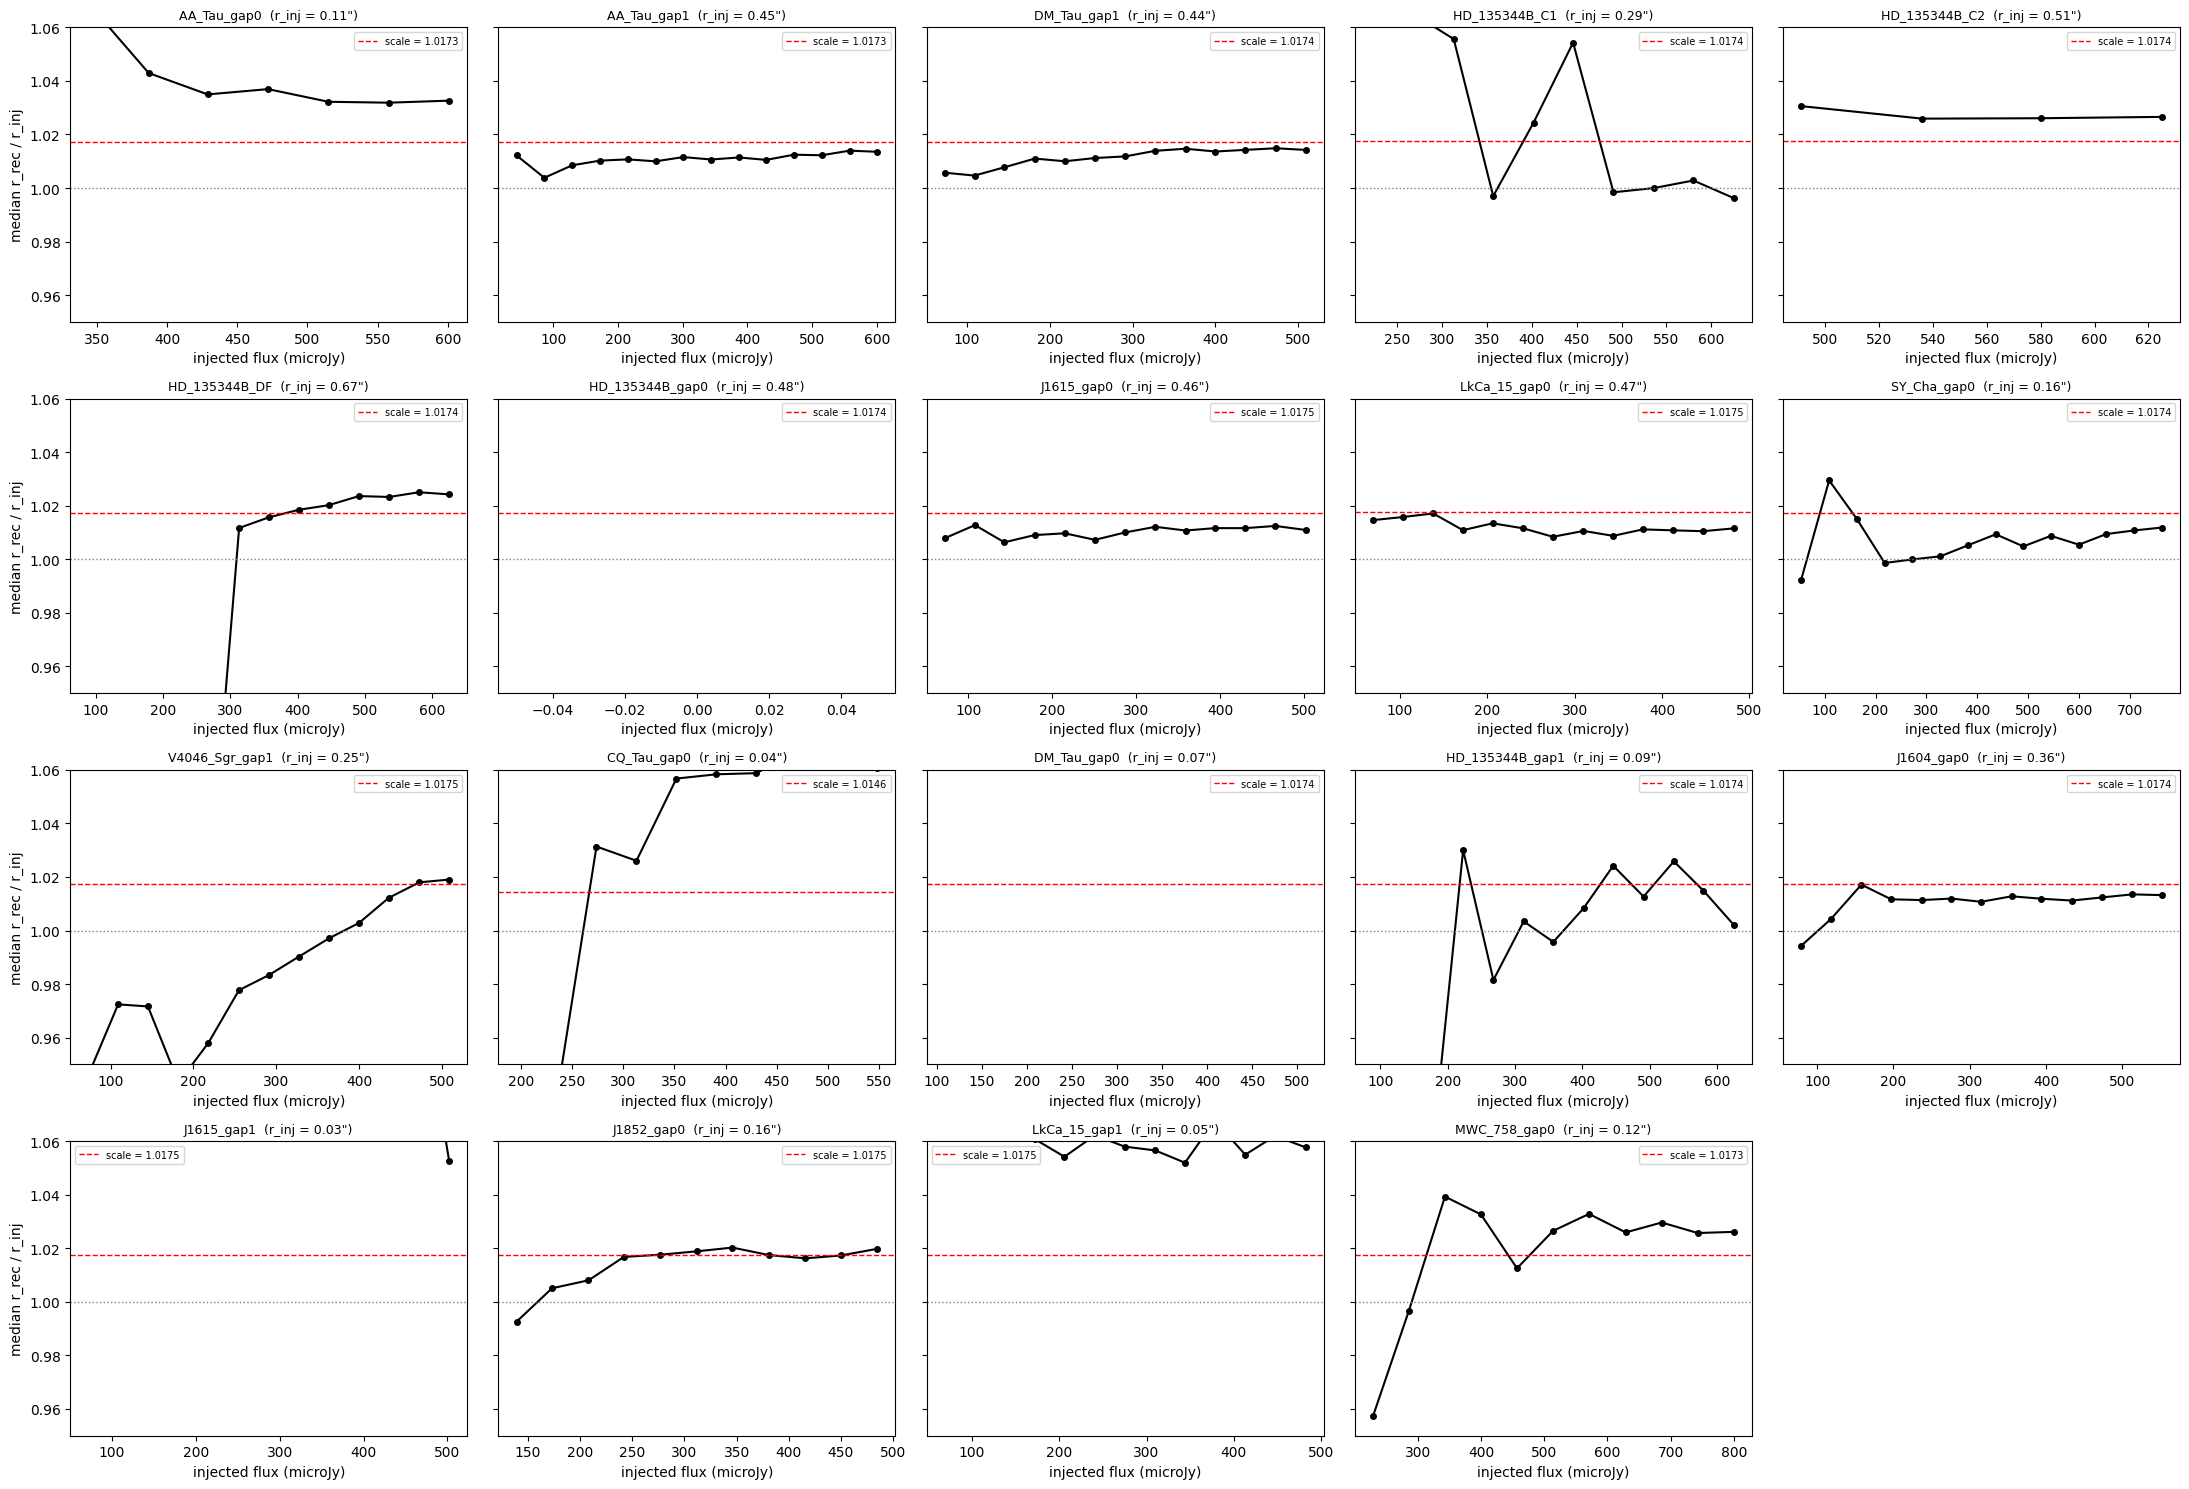

In [3]:
fig, axs = plt.subplots(4, 5, figsize=(22, 15), sharey=True)
for ax, r in zip(axs.flat, R):
    med = [np.median(r['ratio_all'][r['rec_A_old'] & (r['Fi'] == F)]) if np.sum(r['rec_A_old'] & (r['Fi'] == F)) > 5 else np.nan for F in r['Fcpd']]
    ax.plot(r['Fcpd'], med, 'ko-', ms=4)
    ax.axhline(r['scale'], color='r', ls='--', lw=1, label=f"scale = {r['scale']:.4f}")
    ax.axhline(1, color='grey', ls=':', lw=1)
    ax.set_title(f"{r['folder']}  (r_inj = {r['r_inj']:.2f}\")", fontsize=9)
    ax.set_xlabel('injected flux (microJy)')
    ax.legend(fontsize=7)
axs[0, 0].set_ylim(0.95, 1.06)
for ax in axs[:, 0]:
    ax.set_ylabel('median r_rec / r_inj')
for ax in axs.flat[len(R):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Check 2: recovery fraction with the original vs the scaled expected position

Filled circles with solid lines use the original expected position; open circles with dashed lines use the scaled one (`scale` × injected position). The 7 clean outer gaps, where the shift is measurable, come first. Vertical lines mark F50: solid for original, dashed for scaled. The table lists F50 for criteria A and B, along with the flux-bin width.

folder                     bin F50_A old F50_A new F50_B old F50_B new   (microJy)
AA_Tau_gap1                 43     254.6     232.8     194.0     192.2
DM_Tau_gap1                 36     187.3     156.8     101.0      98.4
J1604_gap0                  39     211.8     197.7     156.3     159.7
J1615_gap0                  36     205.2     199.0     150.2     151.7
LkCa_15_gap0                34     251.8     207.2     137.0     137.5
SY_Cha_gap0                 54     237.6     236.4      97.4     100.0
J1852_gap0                  35     185.7     187.4     163.3     162.7
AA_Tau_gap0                 43     500.5     493.5     449.2     450.8
HD_135344B_C1               45     441.4     441.4     412.0     410.6
HD_135344B_C2               45       nan       nan       nan       nan
HD_135344B_DF               45      89.0      89.0      89.0      89.0
HD_135344B_gap0             45       nan       nan       nan       nan
V4046_Sgr_gap1              36       nan       nan     459.5     

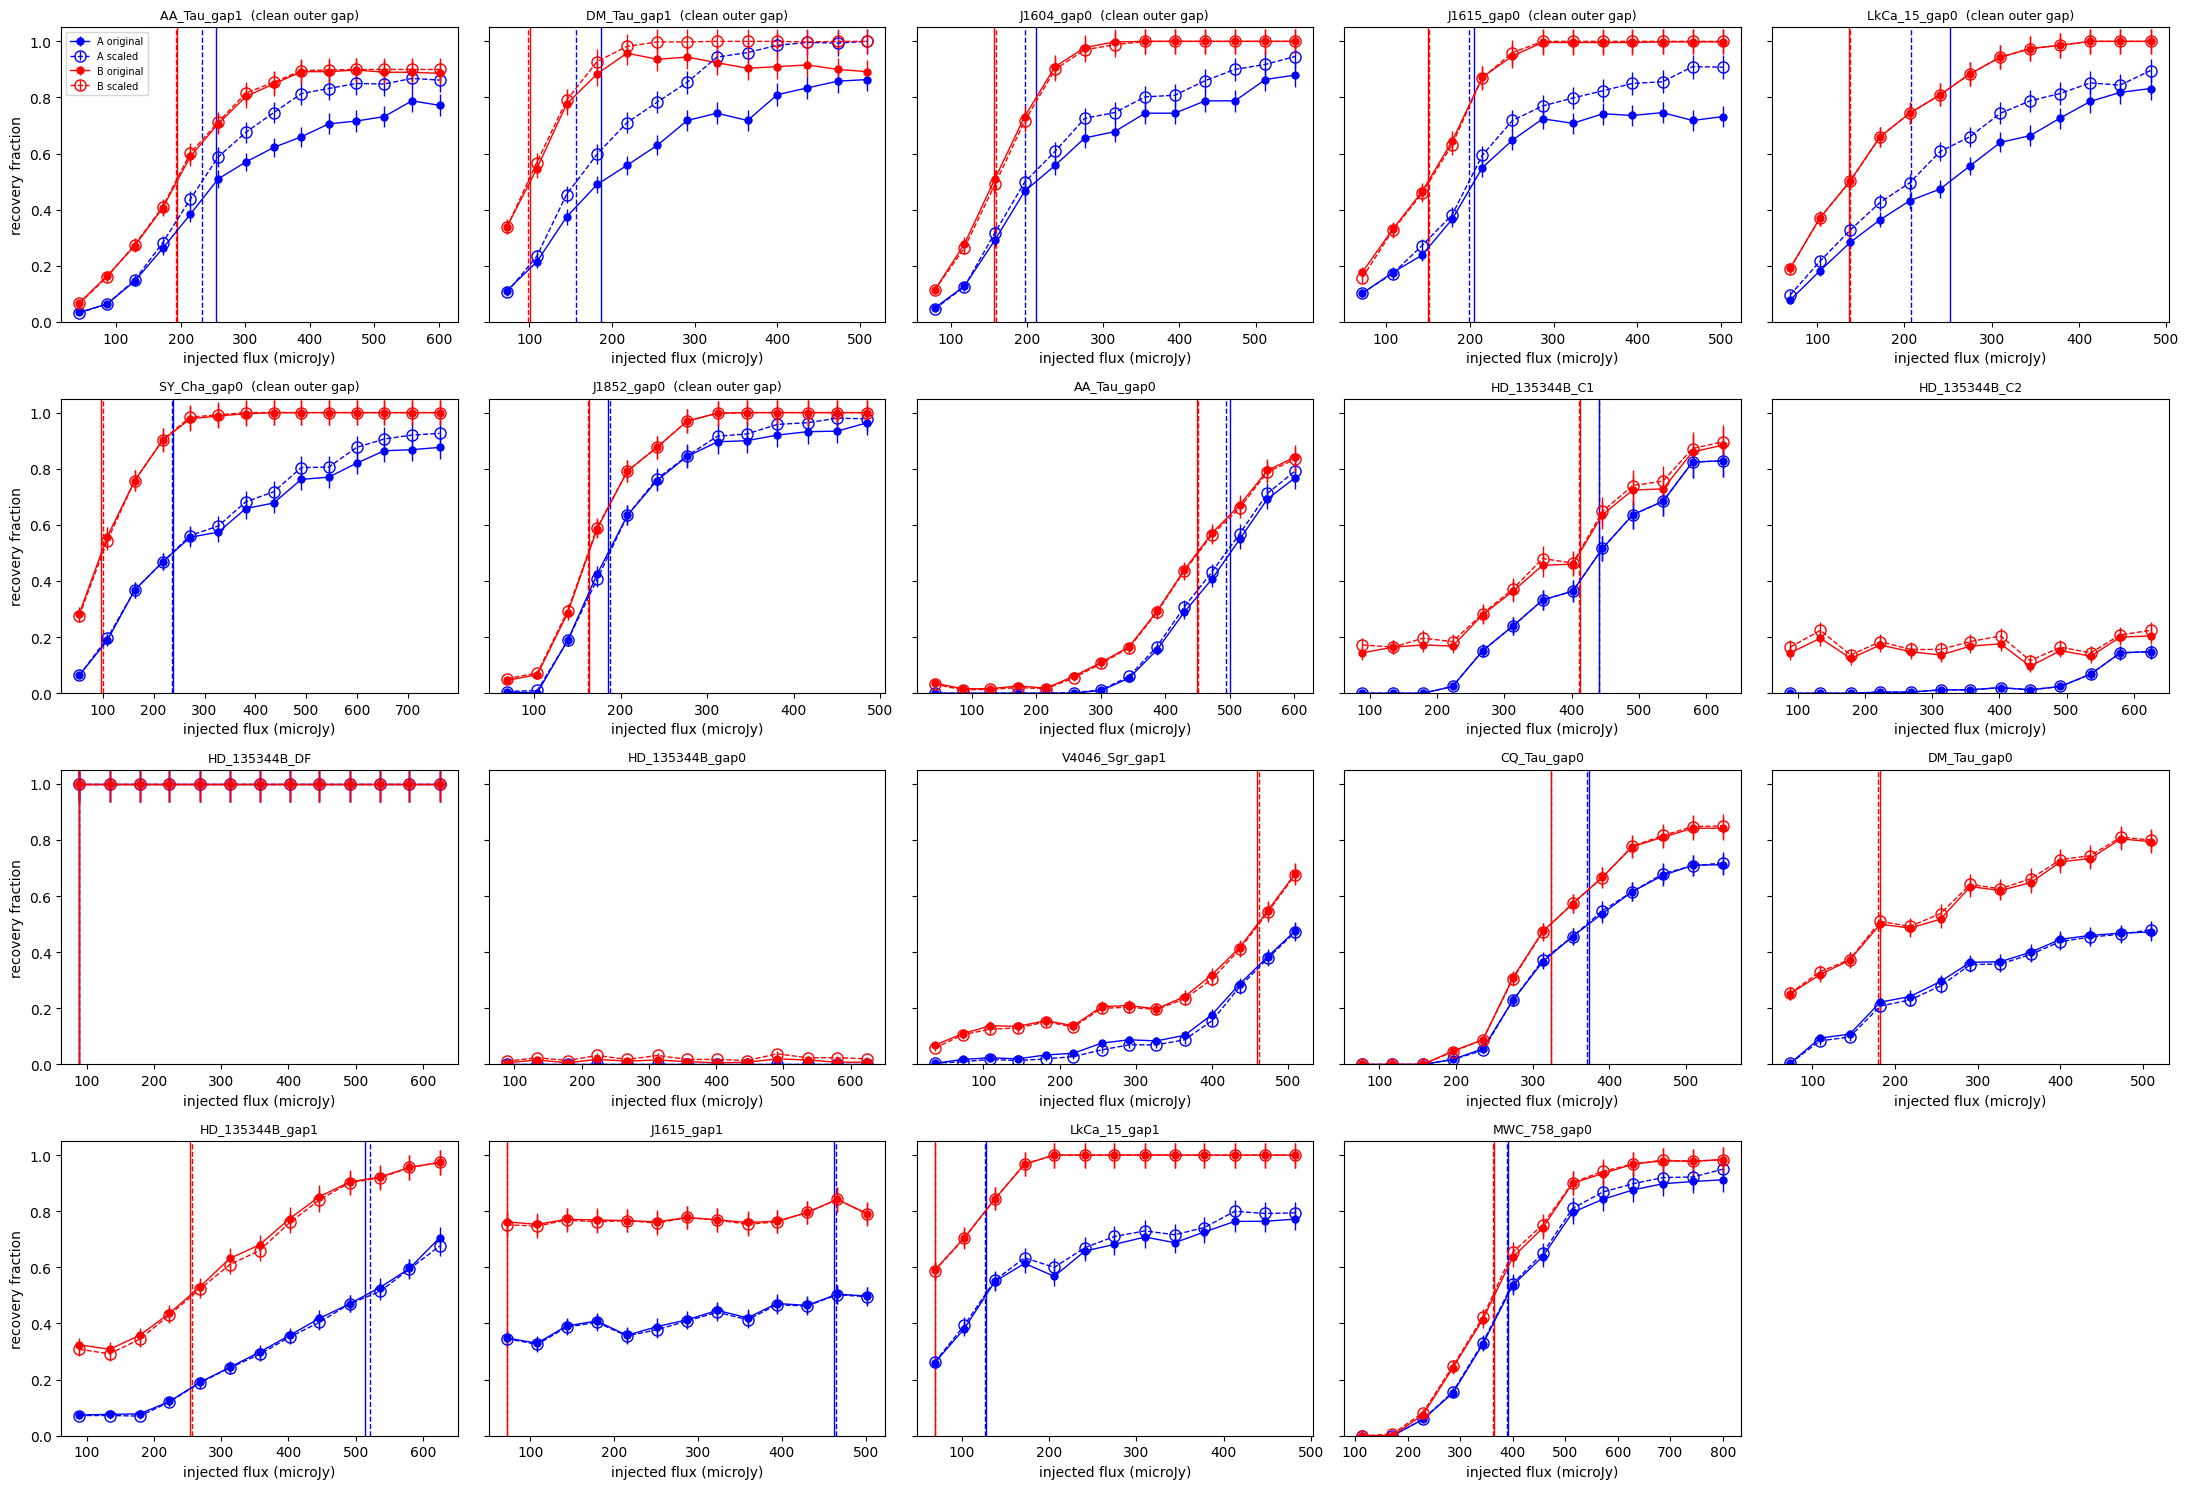

In [4]:
# clean outer gaps first (the shift is measurable there), then the rest
clean = ['AA_Tau_gap1', 'DM_Tau_gap1', 'J1604_gap0', 'J1615_gap0', 'LkCa_15_gap0', 'SY_Cha_gap0', 'J1852_gap0']
R2 = sorted(R, key=lambda r: clean.index(r['folder']) if r['folder'] in clean else len(clean))
fig, axs = plt.subplots(4, 5, figsize=(22, 15), sharey=True)
print(f"{'folder':24s} {'bin':>5s} {'F50_A old':>9s} {'F50_A new':>9s} {'F50_B old':>9s} {'F50_B new':>9s}   (microJy)")
for ax, r in zip(axs.flat, R2):
    F, N = r['Fcpd'], r['N']
    for key, c in [('A', 'b'), ('B', 'r')]:
        old, new = r[f'f{key}_old'], r[f'f{key}_new']
        ax.errorbar(F, old, yerr=np.sqrt(old * N) / N, fmt='o-', color=c, ms=5, lw=1, label=f'{key} original')
        ax.errorbar(F, new, yerr=np.sqrt(new * N) / N, fmt='o--', mfc='none', color=c, ms=8, lw=1, label=f'{key} scaled')
        ax.axvline(F50(F, old), color=c, lw=1)
        ax.axvline(F50(F, new), color=c, lw=1, ls='--')
    ax.set_title(r['folder'] + ('  (clean outer gap)' if r['folder'] in clean else ''), fontsize=9)
    ax.set_xlabel('injected flux (microJy)')
    print(f"{r['folder']:24s} {np.median(np.diff(F)):5.0f} {F50(F, r['fA_old']):9.1f} {F50(F, r['fA_new']):9.1f} {F50(F, r['fB_old']):9.1f} {F50(F, r['fB_new']):9.1f}")
axs[0, 0].set_ylim(0, 1.05)
axs[0, 0].legend(fontsize=7)
for ax in axs[:, 0]:
    ax.set_ylabel('recovery fraction')
for ax in axs.flat[len(R):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()